# Моделирование Аналитического модуля

### Import

In [133]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import root_mean_squared_error, mean_absolute_error, r2_score
from analysis import compute_psd, parse_rr, calc_stress
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import confusion_matrix
from joblib import dump

### Load data

In [112]:
df = pd.read_csv(r'..\raw_data\sambo_train.csv',parse_dates=['Дата обследования'])
df.columns = ['name','date','tp','si']
df.head()

,name,date,tp,si
0,trofim,2026-08-26 09:51:00,6465.595313,31.251713
1,trofim,2026-08-25 09:19:00,3387.744399,60.013046
2,trofim,2026-08-24 09:08:00,1487.922991,133.777461
3,trofim,2026-08-22 10:17:00,2229.942885,91.703348
4,trofim,2026-08-21 11:04:00,1541.931508,84.206981


Text(0, 0.5, 'SI, %')

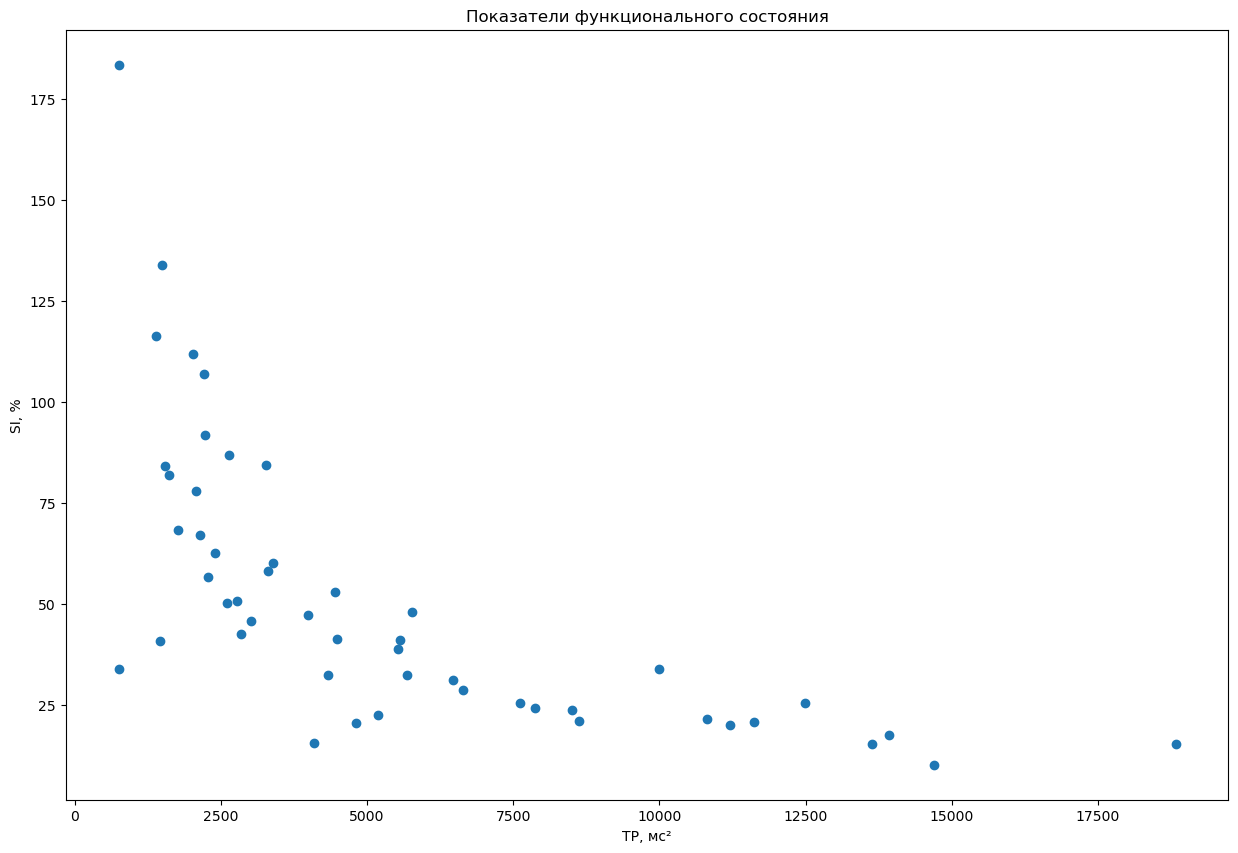

In [113]:
plt.figure(figsize=(15,10))
plt.scatter(df['tp'],df['si'])
plt.title('Показатели функционального состояния')
plt.xlabel('TP, мс²')
plt.ylabel('SI, %')

### EDA - Исследование развития спортсменов

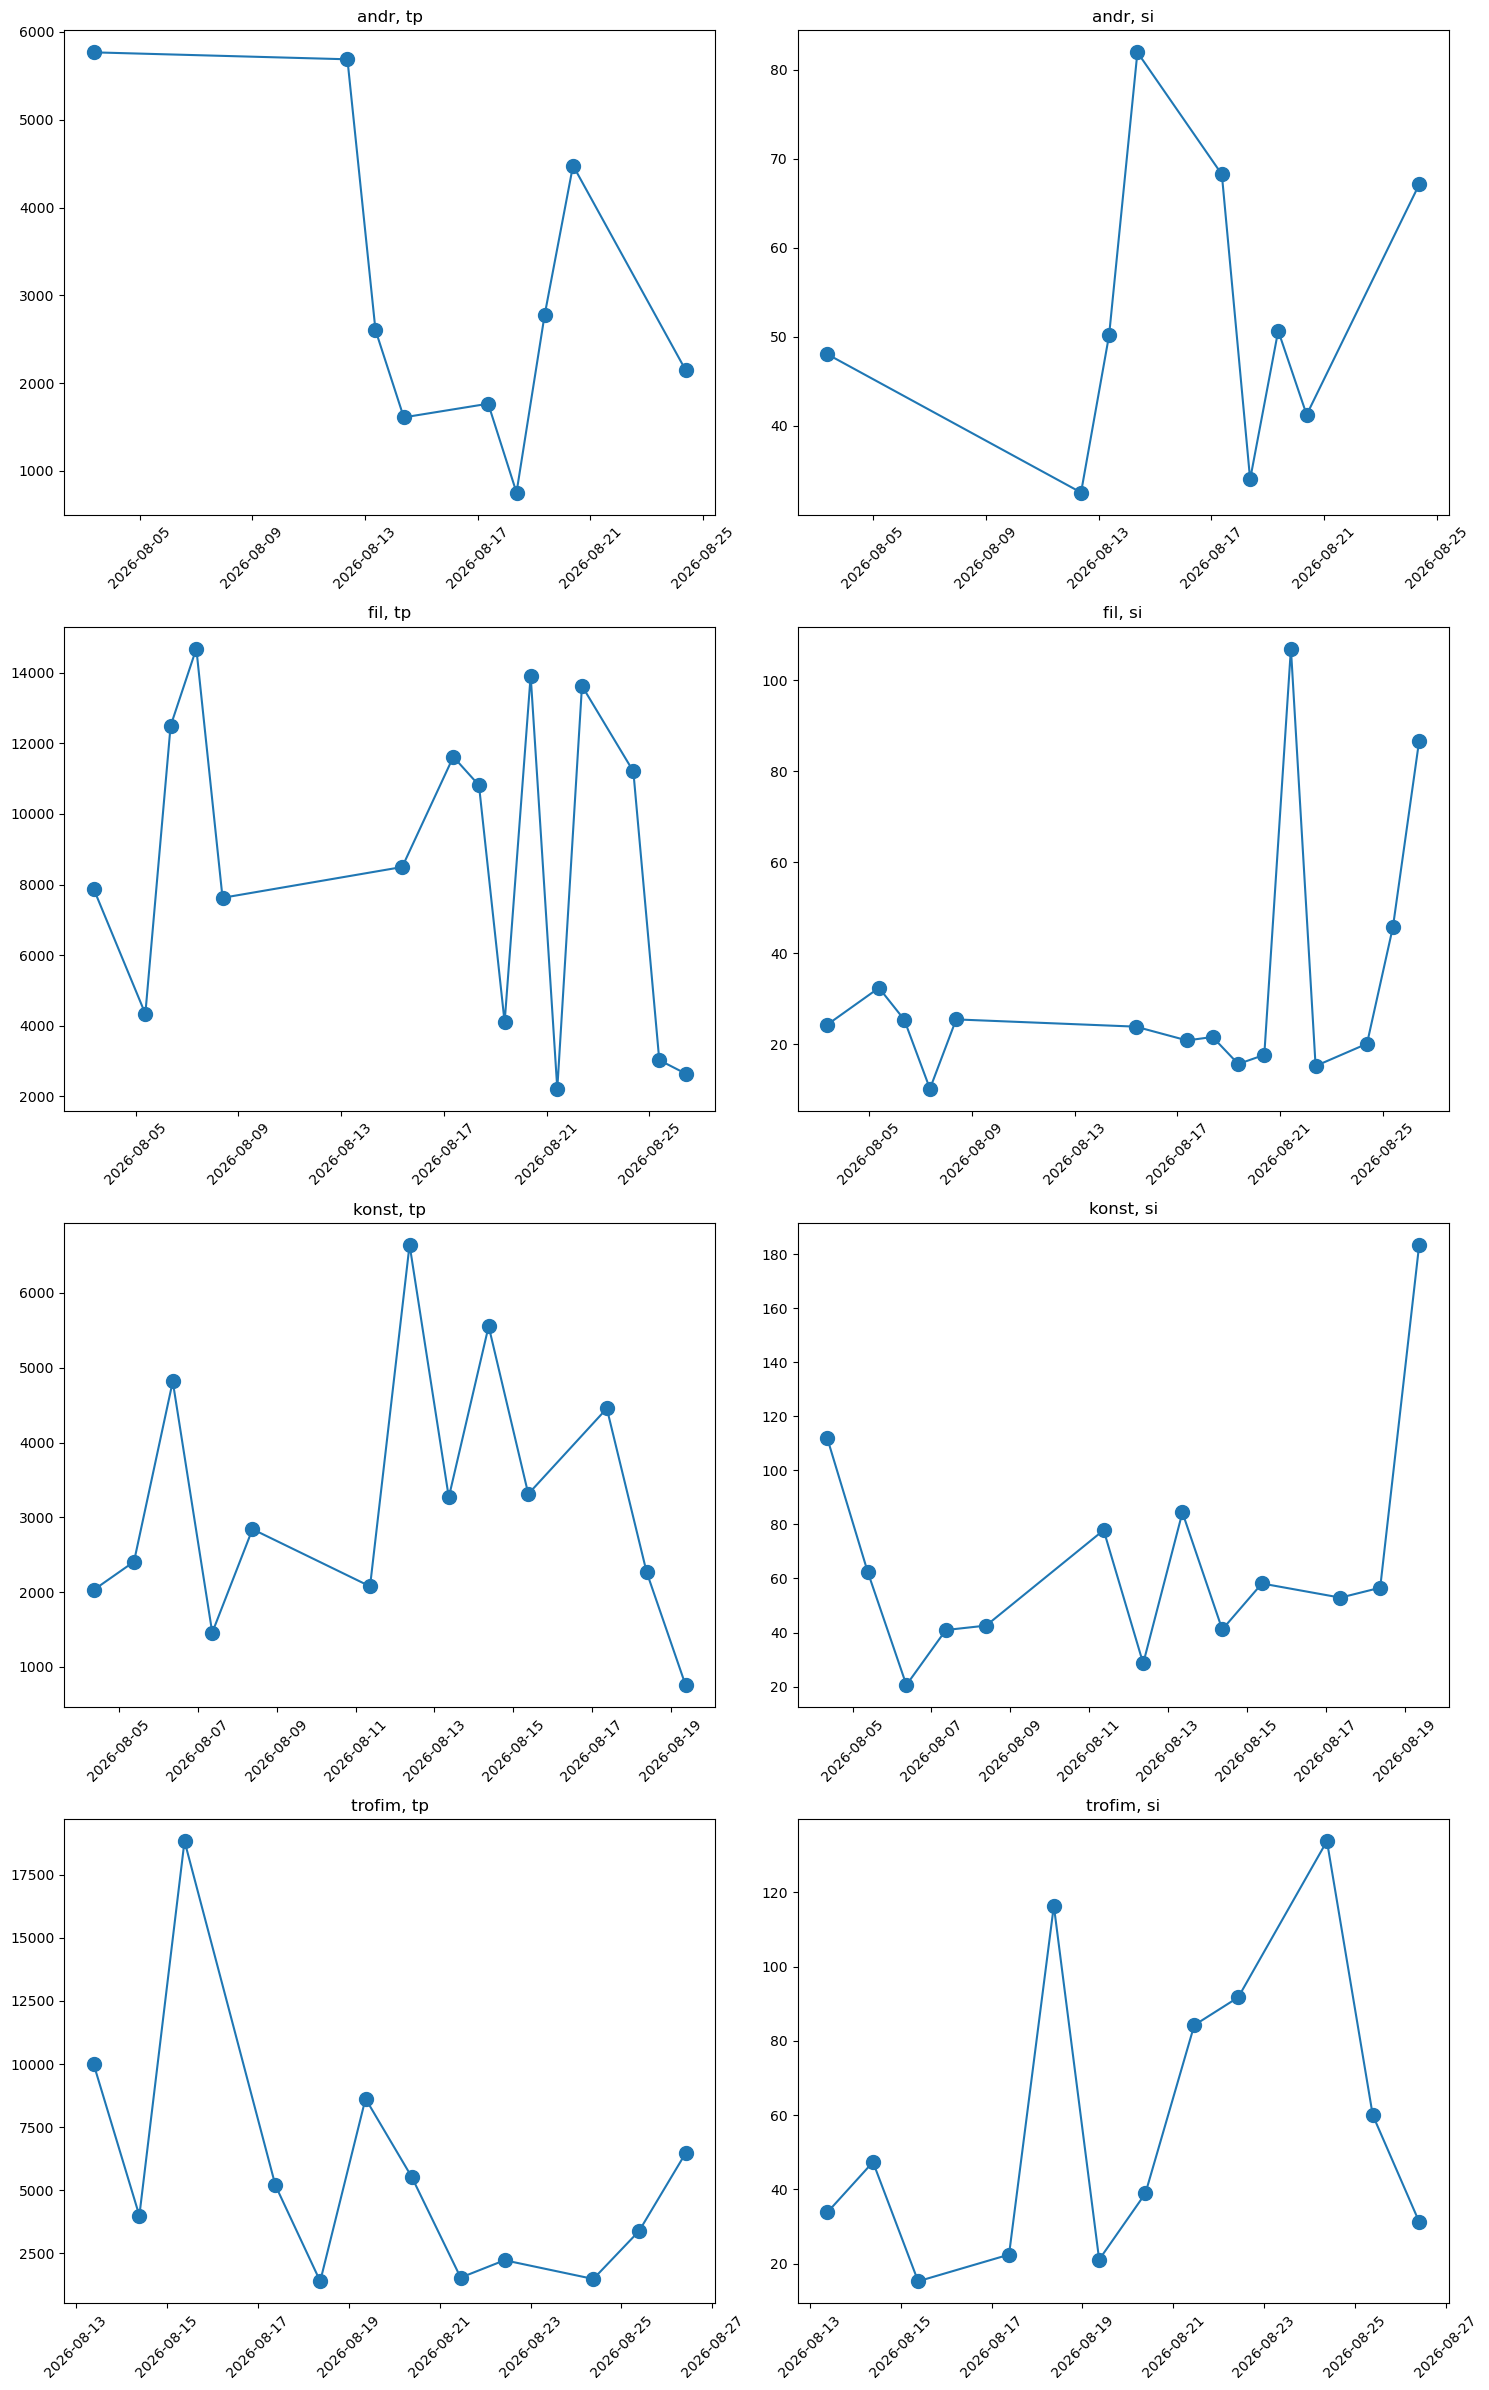

In [114]:
fig, ax = plt.subplots(nrows=len(df['name'].unique()),ncols=2,figsize = (15,len(df['name'].unique())* 6))
for i, (name, group) in enumerate(df.groupby(by='name')):
    ax[i,0].plot(group['date'],group['tp'],marker = 'o',markersize=10)
    ax[i,1].plot(group['date'],group['si'],marker = 'o',markersize=10)
    ax[i,0].set_title(f'{name}, tp')
    ax[i,1].set_title(f'{name}, si')
    ax[i,0].tick_params(axis = 'x', rotation = 45)
    ax[i,1].tick_params(axis = 'x', rotation = 45)

plt.tight_layout()
plt.show()


### Andrey decision

In [115]:
andrey_mask = df['name']=='andr'
df.loc[(andrey_mask) & 
        (df['tp'] > 4000) ,'target'] = 'Повышенная нагрузка'
df.loc[(andrey_mask) & 
        (df['tp'] < 4000) & 
        (df['tp'] >= 2000) ,'target'] = 'Средняя нагрузка'
df.loc[(andrey_mask) & 
        (df['tp'] < 2000) & 
        (df['tp'] >= 1000) ,'target'] = 'Восстановление'
df.loc[(andrey_mask) & 
        (df['tp'] < 1000) ,'target'] = 'Освободить от тренировки'

### Fillip decision

In [116]:
fil_mask = df['name']=='fil'
df.loc[(fil_mask) & 
        (df['tp'] >= 9000) ,'target'] = 'Повышенная нагрузка'
df.loc[(fil_mask) & 
        (df['tp'] >= 3000) & 
        (df['tp'] < 9000) ,'target'] = 'Средняя нагрузка'
df.loc[(fil_mask) & 
        (df['tp'] < 3000) & 
        (df['tp'] >= 1000)&
        (df['si'] < 80 ) ,'target'] = 'Восстановление'
df.loc[(fil_mask) & 
        (df['si'] > 80) ,'target'] = 'Освободить от тренировки'

### konst decision

In [117]:
konst_mask = df['name']=='konst'
df.loc[(konst_mask) & 
        (df['tp'] >= 5000) ,'target'] = 'Повышенная нагрузка'
df.loc[(konst_mask) & 
        (df['tp'] < 5000) & 
        (df['tp'] >= 2500) ,'target'] = 'Средняя нагрузка'
df.loc[(konst_mask) & 
        (df['tp'] < 2500) & 
        (df['tp'] >= 1000)&
        (df['si'] < 100 ) ,'target'] = 'Восстановление'
df.loc[(konst_mask) & 
        (df['si'] > 100) ,'target'] = 'Освободить от тренировки'

### trofim decision

In [118]:
trofim_mask = df['name']=='trofim'
df.loc[(trofim_mask) & 
        (df['tp'] >= 7000) ,'target'] = 'Повышенная нагрузка'
df.loc[(trofim_mask) & 
        (df['tp'] < 7000) & 
        (df['tp'] >= 2500) ,'target'] = 'Средняя нагрузка'
df.loc[(trofim_mask) & 
        (df['tp'] < 2500) & 
        (df['tp'] >= 500)&
        (df['si'] < 100 ) ,'target'] = 'Восстановление'
df.loc[(trofim_mask) & 
        (df['si'] > 100) ,'target'] = 'Освободить от тренировки'

### Проверка на заполненноть DF

In [119]:
df[df['target'].isna()]

,name,date,tp,si,target


Text(0, 0.5, 'SI, %')

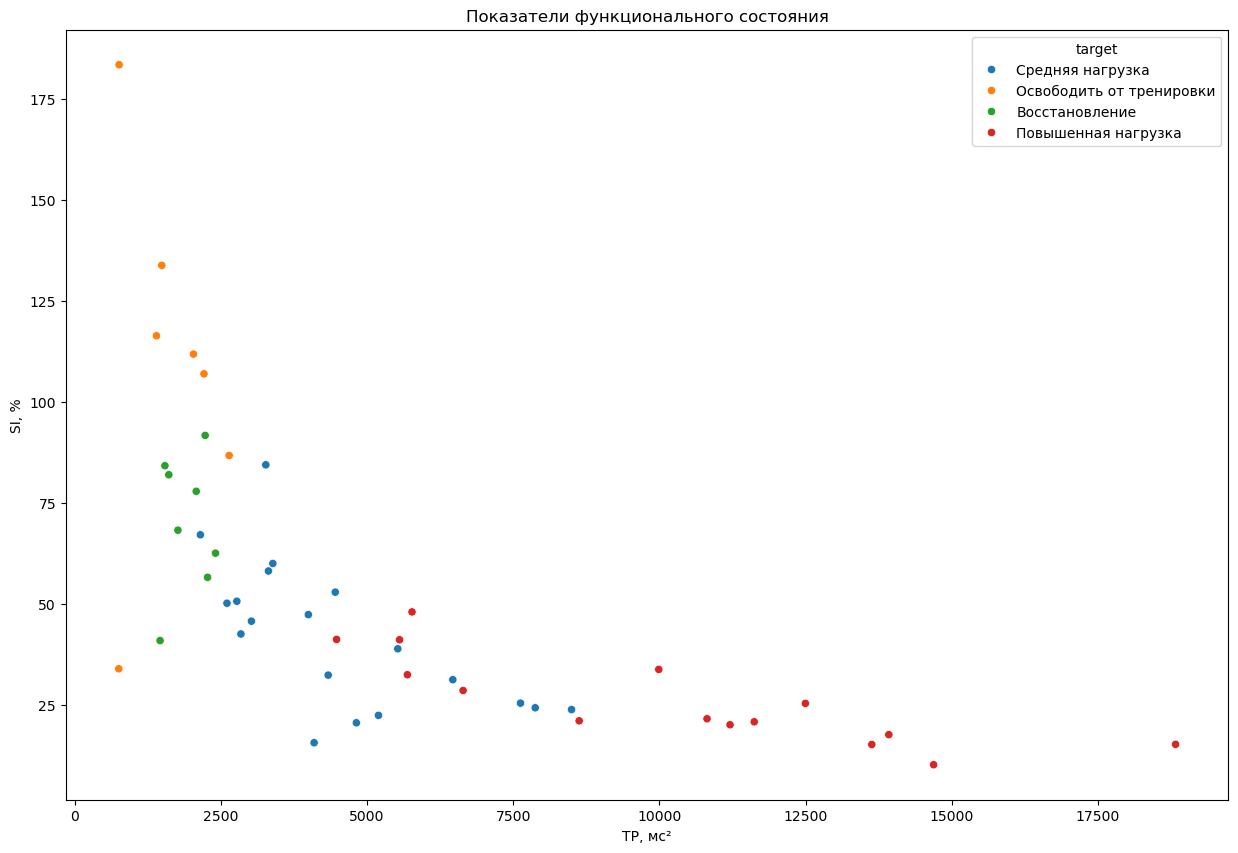

In [120]:
plt.figure(figsize=(15,10))
sns.scatterplot(df,x='tp',y='si',hue='target')
plt.title('Показатели функционального состояния')
plt.xlabel('TP, мс²')
plt.ylabel('SI, %')

### Создание признака - максимальная форма за 10 записей - peak_10_tp

In [121]:
df = df.sort_values(by='date').reset_index(drop=True)
# Если нужно считать внутри каждой "категории" отдельно:
df['peak_10_tp'] = (
    df.groupby('name')['tp']
    .rolling(window=10, min_periods=1)
    .max()
    .reset_index(level=0, drop=True) # убираем индекс группировки для корректной записи в df
)

### Создание признака - доля от максимальной формы (TP) - tp_level

In [122]:
df['tp_level'] = df['tp'] / df['peak_10_tp']

In [123]:
df

,name,date,tp,si,target,peak_10_tp,tp_level
0,fil,2026-08-03 08:54:00,7875.381784,24.308851,Средняя нагрузка,7875.381784,1.000000
1,andr,2026-08-03 08:59:00,5768.079029,48.027920,Повышенная нагрузка,5768.079029,1.000000
2,konst,2026-08-04 08:38:00,2029.659660,111.816875,Освободить от тренировки,2029.659660,1.000000
3,konst,2026-08-05 09:09:00,2406.958504,62.563975,Восстановление,2406.958504,1.000000
4,fil,2026-08-05 09:09:00,4334.283693,32.390133,Средняя нагрузка,7875.381784,0.550359
5,fil,2026-08-06 08:45:00,12495.876842,25.397311,Повышенная нагрузка,12495.876842,1.000000
6,konst,2026-08-06 08:45:00,4816.423597,20.590797,Средняя нагрузка,4816.423597,1.000000
7,konst,2026-08-07 08:47:00,1459.076292,40.936786,Восстановление,4816.423597,0.302938
8,fil,2026-08-07 08:47:00,14689.594538,10.216505,Повышенная нагрузка,14689.594538,1.000000
9,konst,2026-08-08 09:16:00,2841.561917,42.569739,Средняя нагрузка,4816.423597,0.589973


Text(0, 0.5, 'SI, %')

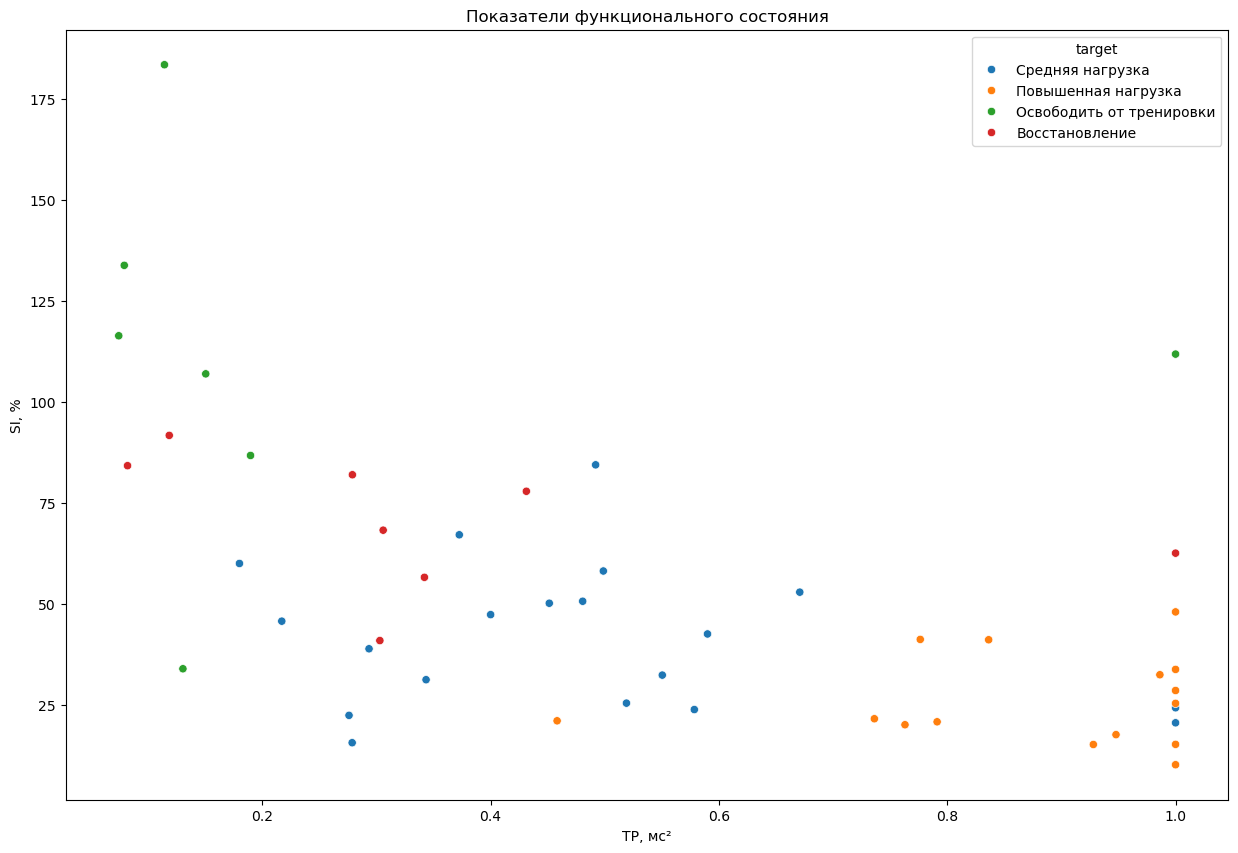

In [124]:
plt.figure(figsize=(15,10))
sns.scatterplot(df,x='tp_level',y='si',hue='target')
plt.title('Показатели функционального состояния')
plt.xlabel('TP, мс²')
plt.ylabel('SI, %')

### Modeling

Подготовка признаков и целевой переменной

In [125]:
features = df[['tp','si','tp_level']]
target = df['target']

In [126]:
X_train, X_test, y_train, y_test = train_test_split(features,target,test_size = 0.2,random_state = 21)

Обучение модели

In [127]:
param_grid = {
    'criterion': ['gini', 'entropy', 'log_loss'],
    'max_depth': [None, 3, 5, 7, 10, 15],
}

In [128]:
model = DecisionTreeClassifier()

In [129]:
grid_search = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    cv=5,
)

In [130]:
grid_search.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=DecisionTreeClassifier(),
             param_grid={'criterion': ['gini', 'entropy', 'log_loss'],
                         'max_depth': [None, 3, 5, 7, 10, 15]})

In [131]:
model.set_params(**grid_search.best_params_)
model.fit(X_train,y_train)
y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)

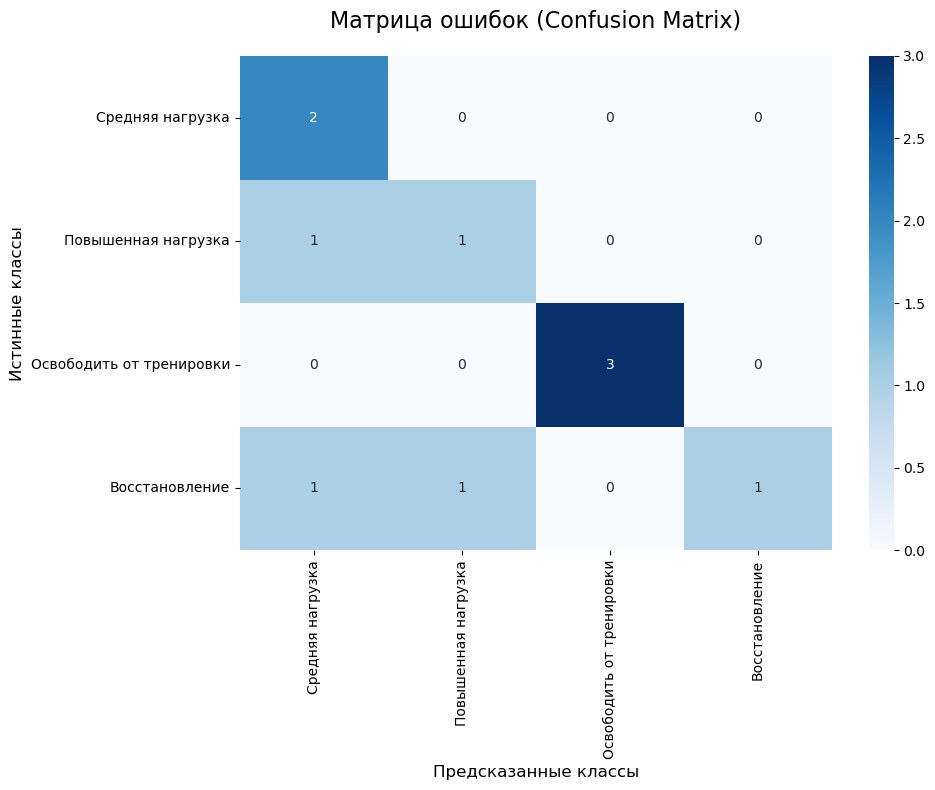

In [132]:
cm = confusion_matrix(y_test, y_pred_test)

# 2. Настраиваем размер графика
plt.figure(figsize=(10, 8))

# 3. Строим heatmap
sns.heatmap(
    cm,
    annot=True,  # Выводить числа внутри ячеек
    fmt='d',  # Формат чисел (целые числа)
    cmap='Blues',  # Цветовая палитра
    xticklabels=df['target'].unique(),  # Названия классов по оси X
    yticklabels=df['target'].unique(),  # Названия классов по оси Y
)

# 4. Добавляем подписи
plt.title('Матрица ошибок (Confusion Matrix)', fontsize=16, pad=20)
plt.ylabel('Истинные классы', fontsize=12)
plt.xlabel('Предсказанные классы', fontsize=12)

plt.tight_layout()
plt.show()

### Сохранение модели

In [134]:
dump(model,'../raw_data/model.pth')

['../raw_data/model.pth']

In [ ]:
# from matplotlib.colors import ListedColormap


# h = 1  # Шаг сетки
# x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
# y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
# xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

# # Предсказываем класс для каждой точки сетки
# Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
# Z = Z.reshape(xx.shape)

# # Цветовые карты: светлые для фона, яркие для точек данных
# cmap_light = ListedColormap(['#FFAAAA', '#AAFFAA', '#AACCFF'])
# cmap_bold = ['#FF0000', '#00FF00', '#0000FF']

# # 4. Создаем график с двумя полями (1 строка, 2 колонки)
# fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7), sharex=True, sharey=True)

# # --- ЛЕВОЕ ПОЛЕ: Обучающая выборка ---
# # Заливка фона предсказаниями модели
# ax1.pcolormesh(xx, yy, Z, cmap=cmap_light, shading='auto')
# # Отображение точек обучающей выборки
# sns_plot1 = ax1.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap=ListedColormap(cmap_bold),
#                         edgecolors='k', s=40)
# ax1.set_title(f"Обучающая выборка (Train)\nAccuracy: {clf.score(X_train, y_train):.2f}", fontsize=14)
# ax1.set_xlabel("Признак 1")
# ax1.set_ylabel("Признак 2")

# # --- ПРАВОЕ ПОЛЕ: Тестовая выборка ---
# # Заливка фона точно такая же (модель-то одна)
# ax2.pcolormesh(xx, yy, Z, cmap=cmap_light, shading='auto')
# # Отохражение точек тестовой выборки
# ax2.scatter(X_test[:, 0], X_test[:, 1], c=y_test, cmap=ListedColormap(cmap_bold),
#             edgecolors='k', s=40)
# ax2.set_title(f"Тестовая выборка (Test)\nAccuracy: {clf.score(X_test, y_test):.2f}", fontsize=14)
# ax2.set_xlabel("Признак 1")

# plt.suptitle("Разделяющая поверхность Decision Tree на двух выборках", fontsize=16, y=1.02)
# plt.tight_layout()
# plt.show()
